Regressions

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import networkx as nx

In [16]:
PATH = '/climca/people/glattus/Hindcast_data_ready'

def df_xr_prep(df):
    da=df.to_xarray()
    da=da.rename({'index':'year'})
    return da

##La Plata
#SON
era_SON_LaPlata_xr=xr.open_dataset(PATH+'/Target_vars_LP_SON.nc')

In [17]:
era_SON_LaPlata_xr

<xarray.Dataset> Size: 951kB
Dimensions:                  (sample: 6426)
Coordinates:
    lead_block               (sample) <U10 257kB ...
    forecast_reference_time  (sample) datetime64[ns] 51kB ...
    number                   (sample) int64 51kB ...
    real_season              (sample) <U3 77kB ...
    real_months              (sample) <U8 206kB ...
    season_label             (sample) <U8 206kB ...
Dimensions without coordinates: sample
Data variables:
    t2m                      (sample) float64 51kB ...
    tprate                   (sample) float64 51kB ...

In [ ]:
##La Plata
#SON

#era_SON_LaPlata_df=era_SON_LaPlata_df.rename(index_col='year')
era_SON_LaPlata_array=era_SON_LaPlata_df.to_xarray()
era_SON_LaPlata_array=era_SON_LaPlata_array.rename({'index':'year'})


In [7]:
era_SON_LaPlata_array

<xarray.Dataset> Size: 7kB
Dimensions:         (year: 73)
Coordinates:
  * year            (year) int64 584B 1951 1952 1953 1954 ... 2023 2024 1950
Data variables:
    t_LaPlata       (year) float64 584B 1.008 -0.3405 0.001028 ... 1.963 nan
    precip_LaPlata  (year) float64 584B 1.251 -1.636 2.576 ... 1.411 -0.9275 nan
    ENSO            (year) float64 584B 0.8577 -0.08958 0.6573 ... -0.33 nan
    IOD             (year) float64 584B 0.1126 -0.4963 0.1753 ... 0.8168 nan
    EDJ             (year) float64 584B -0.4128 -0.3213 0.5606 ... -0.763 nan
    EDJ_lat         (year) float64 584B 1.568 -1.369 0.8338 ... 1.446 nan
    EDJ_lat_nostd   (year) float64 584B -48.64 -53.79 -49.93 ... -48.86 nan
    SPV             (year) float64 584B -1.639 0.7289 -1.065 ... -0.05547 nan
    A_SAM           (year) float64 584B -0.6832 0.7533 0.5528 ... -0.4684 nan
    S_SAM           (year) float64 584B -2.402 -0.386 -1.018 ... 0.9627 nan
    VB_class        (year) object 584B 'Early' 'Early' 'Late' ... 'Late' 'Early'

In [8]:
from Functions import lin_model_fast, conditioning_everything_fast

In [10]:
drivers_SON_xr=xr.open_dataset(PATH+'/ENSO_IOD_SON.nc')

In [12]:
drivers_SON= ['ENSO', 'IOD']
drivers_tot_SON=['ENSO', 'IOD']

In [13]:
drivers_SON_xr

<xarray.Dataset> Size: 951kB
Dimensions:                  (sample: 6426)
Coordinates:
    lead_block               (sample) <U10 257kB ...
    forecast_reference_time  (sample) datetime64[ns] 51kB ...
    number                   (sample) int64 51kB ...
    real_season              (sample) <U3 77kB ...
    real_months              (sample) <U8 206kB ...
    season_label             (sample) <U8 206kB ...
Dimensions without coordinates: sample
Data variables:
    iod_index                (sample) float64 51kB ...
    nino34                   (sample) float64 51kB ...

In [14]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [15]:
def bootstrap_regression(
    target_ds,
    driver_ds,
    target_var,
    driver_vars,
    n_boot=50,
    sample_size=73,
    add_intercept=True
):
    """
    target_var: string, e.g. "tprate" or "t2m"
    driver_vars: list of strings, e.g. ["nino34"] or ["nino34", "iod_index"]
    """

    results = []

    n_samples = target_ds.sizes["sample"]

    for i in range(n_boot):

        idx = np.random.choice(n_samples, size=sample_size, replace=True)

        y = target_ds[target_var].isel(sample=idx).values

        X = pd.DataFrame({
            var: driver_ds[var].isel(sample=idx).values
            for var in driver_vars
        })

        df = X.copy()
        df["target"] = y
        df = df.dropna()

        X_clean = df[driver_vars]
        y_clean = df["target"]

        if add_intercept:
            X_clean = sm.add_constant(X_clean)

        model = sm.OLS(y_clean, X_clean).fit()

        row = {
            "bootstrap": i,
            "target": target_var,
            "drivers": "+".join(driver_vars),
            "r2": model.rsquared
        }

        for name, value in model.params.items():
            row[f"coef_{name}"] = value

        results.append(row)

    return pd.DataFrame(results)

In [23]:
results_nino = bootstrap_regression(
    target_ds=era_SON_LaPlata_xr,
    driver_ds=drivers_SON_xr,
    target_var="tprate",
    driver_vars=["nino34"],
    n_boot=100,
    sample_size=73
)

In [24]:
results_multi = bootstrap_regression(
    target_ds=era_SON_LaPlata_xr,
    driver_ds=drivers_SON_xr,
    target_var="tprate",
    driver_vars=["nino34", "iod_index"],
    n_boot=100,
    sample_size=73
)

In [25]:
def plot_bootstrap_coefficients(results, driver_vars, title="Bootstrap regression coefficients"):

    plt.figure(figsize=(8, 5))

    for var in driver_vars:
        plt.hist(
            results[f"coef_{var}"],
            bins=15,
            alpha=0.6,
            label=var
        )

        plt.axvline(
            results[f"coef_{var}"].mean(),
            linestyle="--"
        )

    plt.xlabel("Regression coefficient")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

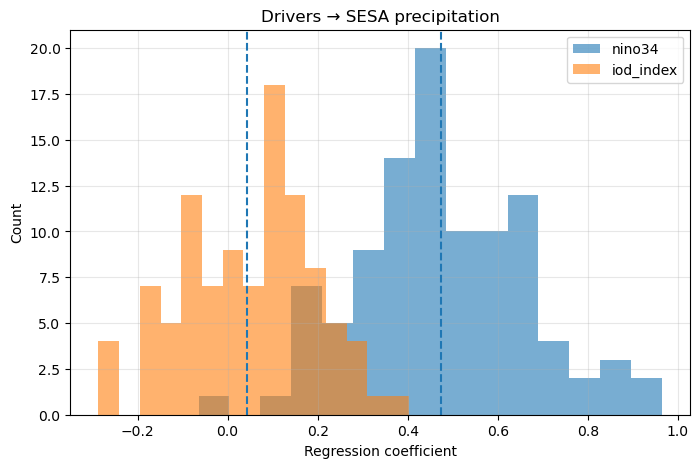

In [26]:
plot_bootstrap_coefficients(
    results_multi,
    driver_vars=["nino34", "iod_index"],
    title="Drivers → SESA precipitation"
)

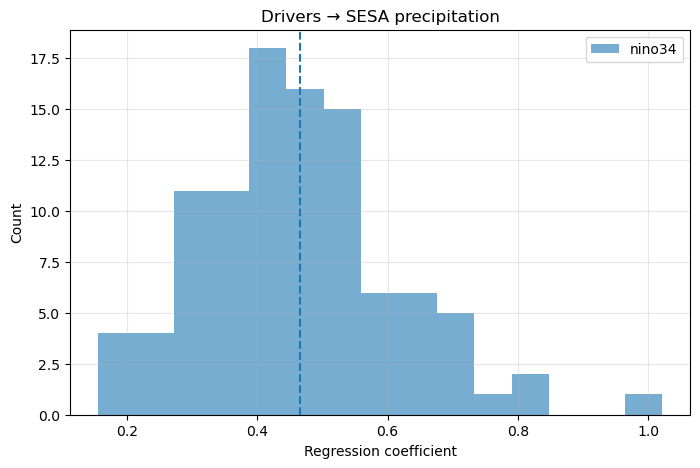

In [27]:
plot_bootstrap_coefficients(
    results_nino,
    driver_vars=["nino34"],
    title="Drivers → SESA precipitation"
)